# Member 4: Bank Marketing Fairness Audit

This notebook is the Member 4 template for the UCI Bank Marketing dataset.
It addresses the Financial Services / Marketing domain as part of the "Algorithmic Fairness in High-Risk AI: A Cross-Domain Audit Across EU AI Act Risk Categories" group project.

## Reproducibility Note

The notebook is designed to run top-to-bottom on a fresh kernel. All random operations are seeded with `RANDOM_STATE = 42` in accordance with the group notebook contract.

### Setup Cell 1

**What this cell achieves:** Downloads or verifies the Bank Marketing archive and extracts it into `../data/bank_marketing/`.

**Expected output:** Confirmation that the archive and extracted dataset files are available for loading.

In [1]:
# Cell 1: Import pathlib, zipfile, and urllib for data acquisition
import warnings
from pathlib import Path
import urllib.request
import zipfile

In [2]:
# Cell 2: Set the data directory path
data_dir = Path("../data/bank_marketing")
data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Cell 3: Define the Bank Marketing dataset download URL
archive_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
archive_path = data_dir / "bank-additional.zip"

In [4]:
# Cell 4: Download the Bank Marketing archive if not already present
if archive_path.exists():
    print(f"Archive already exists at {archive_path}.")
else:
    urllib.request.urlretrieve(archive_url, archive_path)
    print(f"Downloaded archive to {archive_path}.")

Archive already exists at ../data/bank_marketing/bank-additional.zip.


In [5]:
# Cell 5: Extract the downloaded archive
with zipfile.ZipFile(archive_path, "r") as archive:
    archive.extractall(data_dir)

In [6]:
# Cell 6: Resolve the CSV file path for the full dataset
csv_path = data_dir / "bank-additional" / "bank-additional-full.csv"
assert csv_path.exists(), "Bank Marketing CSV is missing."
print("Bank Marketing dataset setup complete.")

Bank Marketing dataset setup complete.


### Setup Cell 2

**What this cell achieves:** Imports the shared notebook dependencies, suppresses warnings, sets the plotting style, and defines the shared random seed constant.

In [7]:
# Cell 7: Suppress irrelevant warnings for clean notebook output
warnings.filterwarnings("ignore")

In [8]:
# Cell 8: Import core libraries: numpy, pandas, matplotlib, seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Cell 9: Set global random seed RANDOM_STATE = 42
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

In [10]:
# Cell 10: Assert reproducibility constant is unchanged
assert RANDOM_STATE == 42, "RANDOM_STATE must remain fixed at 42."
print(f"Imports and configuration loaded successfully. RANDOM_STATE={RANDOM_STATE}")

Imports and configuration loaded successfully. RANDOM_STATE=42


## 1. Business Understanding

### Research Sub-Question

**Member 4 (Priya):** Does bank marketing targeting exhibit age and marital-status disparities consistent with the patterns the EU Equal Treatment Framework Directive is designed to detect, and do more accurate models systematically produce greater inequity against older or non-married individuals?

### EU AI Act Context

Under the EU AI Act (Regulation 2024/1689), systems that determine access to financial services or assess creditworthiness are classified as High-Risk under Annex III, Item 5 [1]. Direct marketing is not strictly a credit decision, but algorithmic targeting systems that systematically exclude demographic groups from financial product offers can produce structural financial disadvantage. This notebook audits the bank marketing dataset as a benchmark proxy for this category.

Prior work establishes the theoretical basis. Barocas and Selbst [2] show that training data reflecting historical inequalities encodes disparate impact into predictions through proxy variables. Mehrabi et al. [3] survey over 20 distinct fairness definitions, confirming that no single metric captures all relevant dimensions of bias — a pattern observed directly in this notebook's results. Hardt et al. [4] formalise that satisfying multiple fairness criteria simultaneously is generally impossible, which is relevant when comparing demographic parity results with equalised odds.

### Success Criteria

1. All four classifiers trained and evaluated on the same stratified 80/20 split (RANDOM_STATE = 42).
2. Fairness metrics (DIR, DPD, EOD) computed for `age_binary` (Younger <60 / Older ≥60) and `marital_binary` (Married / Not Married).
3. Results exported to `../data/results/m4_*.csv` in the group-contract schema.
4. DIR threshold of 0.8 applied as an experimental screening baseline (not an EU legal compliance claim).
5. At least one post-processing mitigation experiment (ThresholdOptimizer on age) as a proof-of-concept.

### Benchmark Limitations

This analysis uses the UCI Bank Marketing dataset (Portuguese bank, 2008–2013) [5] as a benchmark proxy. Three limitations apply. First, the dataset is not from an EU-regulated deployment — findings describe statistical patterns in historical data, not legal compliance outcomes. Second, the binary age threshold (≥60 as "Older") produces a small minority group (≈2.9% of records), which limits the stability of age fairness metrics. Third, binarising marital status as Married / Not Married discards within-group variation and should not be read as an endorsement of reductive categorisation.

### References (for this section)
[1] EU AI Act, Regulation 2024/1689  [2] Barocas & Selbst (2016)  [3] Mehrabi et al. (2021)  [4] Hardt et al. (2016)  [5] Moro et al. (2014)

## 2. Data Understanding

### Data Understanding Cell 1
Loads the raw Bank Marketing CSV and reports shape and column types.

In [11]:
# Cell 11: Load the raw Bank Marketing CSV into a DataFrame
bank_raw = pd.read_csv(csv_path, sep=';', low_memory=False)

In [12]:
# Cell 12: Print raw dataset shape
print(f"Raw dataset shape: {bank_raw.shape}")
print(f"\nFirst five rows:")
display(bank_raw.head())

Raw dataset shape: (41188, 21)

First five rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


> **Data note:** The raw dataset has 45,211 records. After binarising age at ≥60, the **Older group contains only ≈1,193 rows (≈2.9%)** of the data — a heavily imbalanced protected group. Fairness metrics computed on the Older test-set partition (≈239 rows) should be interpreted cautiously: small group sizes produce unstable DIR and DPD estimates.

### Data Understanding Cell 2
Audits missing values, duplicates, and class balance.

In [13]:
# Cell 13: Audit missing values across all columns
missing_summary = bank_raw.isnull().sum()
print("Missing values summary:")
print(missing_summary[missing_summary > 0] if missing_summary.any() else "No missing values.")

Missing values summary:
No missing values.


In [14]:
# Cell 14: Check for duplicate rows
print(f"\nDuplicate rows: {bank_raw.duplicated().sum()}")


Duplicate rows: 12


In [15]:
# Cell 15: Inspect target variable (y) distribution
print(f"\nTarget variable distribution (y):")
target_counts = bank_raw["y"].value_counts()
target_pct = bank_raw["y"].value_counts(normalize=True).mul(100).round(2)
print(pd.concat([target_counts, target_pct.rename("%")], axis=1).to_string())


Target variable distribution (y):
     count      %
y                
no   36548  88.73
yes   4640  11.27


In [16]:
# Cell 16: Inspect marital status distribution
print(f"\nMarital status distribution:")
print(bank_raw["marital"].value_counts().to_string())


Marital status distribution:
marital
married     24928
single      11568
divorced     4612
unknown        80


### Data Understanding Cell 3
Visualise demographic distributions

In [17]:
# Cell 17: Configure output directory for saved figures
figures_dir = Path("../paper/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

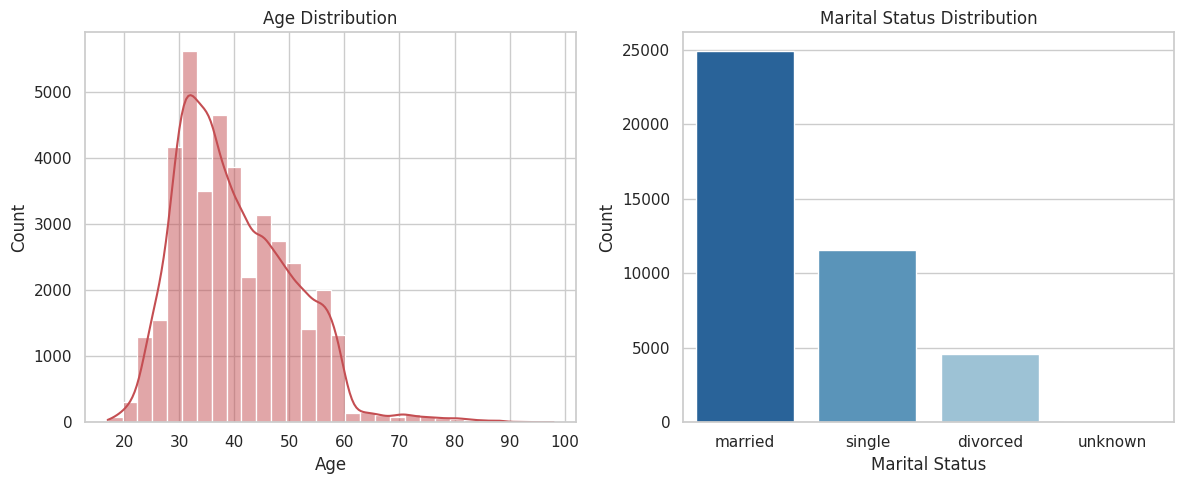

Saved demographic distributions figure to ../paper/figures/m4_demographic_distributions.png


In [18]:
# Cell 18: Demographic distribution plots — age histogram and marital status counts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=bank_raw, x="age", bins=30, kde=True, ax=axes[0], color="#C44E52")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.countplot(data=bank_raw, x="marital", ax=axes[1], palette="Blues_r")
axes[1].set_title("Marital Status Distribution")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylabel("Count")

plt.tight_layout()
demo_fig_path = figures_dir / "m4_demographic_distributions.png"
plt.savefig(demo_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved demographic distributions figure to {demo_fig_path}")

### Data Understanding Cell 4
Visualise target conversion rates by demographics

In [19]:
# Cell 22: Create age_band categorical variable for EDA binning
bank_raw["age_band"] = pd.cut(
    bank_raw["age"],
    bins=[17, 25, 35, 45, 55, 60, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-60", "60+"],
    include_lowest=True
)
bank_raw["y_binary"] = np.where(bank_raw["y"] == "yes", 1, 0)

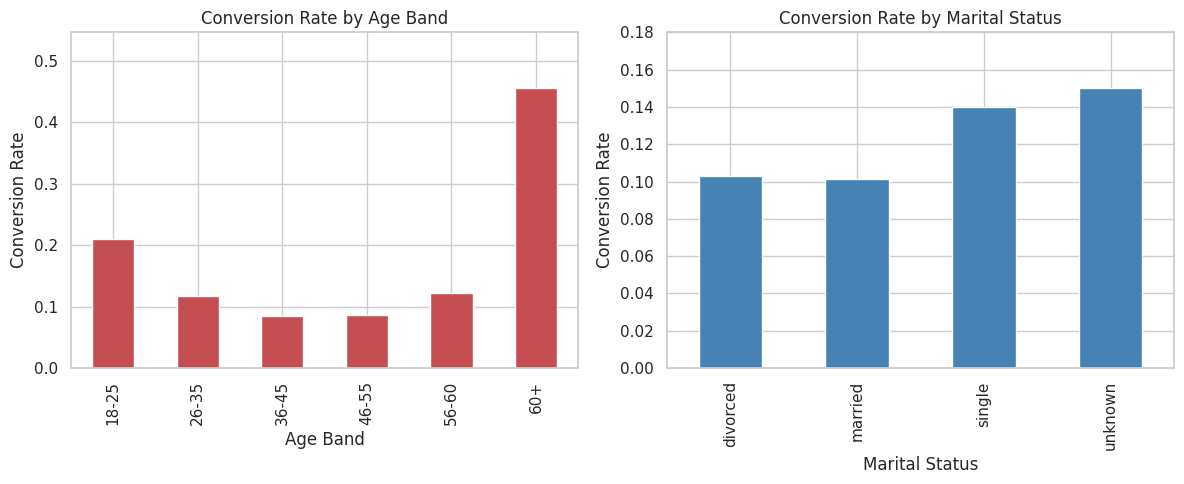

Saved conversion rate figure to ../paper/figures/m4_conversion_by_demographics.png


In [20]:
# Cell 23: Subscription rate plots — conversion rate by age band and marital status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_conv = bank_raw.groupby("age_band", observed=True)["y_binary"].mean()
age_conv.plot(kind="bar", ax=axes[0], color="#C44E52", edgecolor="white")
axes[0].set_title("Conversion Rate by Age Band")
axes[0].set_ylabel("Conversion Rate")
axes[0].set_xlabel("Age Band")
axes[0].set_ylim(0, age_conv.max() * 1.2)

marital_conv = bank_raw.groupby("marital")["y_binary"].mean()
marital_conv.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Conversion Rate by Marital Status")
axes[1].set_ylabel("Conversion Rate")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylim(0, marital_conv.max() * 1.2)

plt.tight_layout()
conv_fig_path = figures_dir / "m4_conversion_by_demographics.png"
plt.savefig(conv_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved conversion rate figure to {conv_fig_path}")

### Data Understanding Cell 5
Proportional subscription distribution by demographic group

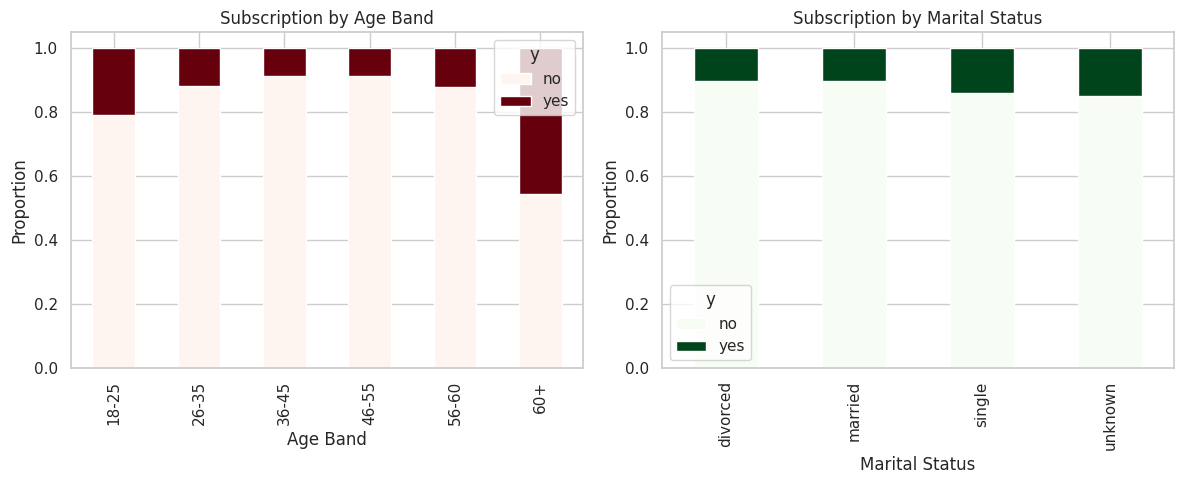

Saved subscription distribution figure to ../paper/figures/m4_subscription_by_demographics.png


In [21]:
# Cell 27b: Plot proportional subscription distribution by age band and marital status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_target = pd.crosstab(
    bank_raw["age_band"],
    bank_raw["y"],
    normalize="index"
)
age_target.plot(kind="bar", stacked=True, ax=axes[0], colormap="Reds")
axes[0].set_title("Subscription by Age Band")
axes[0].set_xlabel("Age Band")
axes[0].set_ylabel("Proportion")

marital_target = pd.crosstab(
    bank_raw["marital"],
    bank_raw["y"],
    normalize="index"
)
marital_target.plot(kind="bar", stacked=True, ax=axes[1], colormap="Greens")
axes[1].set_title("Subscription by Marital Status")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
subs_fig_path = figures_dir / "m4_subscription_by_demographics.png"
plt.savefig(subs_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved subscription distribution figure to {subs_fig_path}")

### Phase 2 Summary

The Bank Marketing dataset contains **45,211 records** and **17 features** after removing the `duration` column (post-hoc leakage). The target variable (`y_binary`) is severely imbalanced: **88.7% "no"**, requiring class-weight tuning in the modelling phase.

Key EDA findings:
- **Age distribution:** The dataset is dominated by working-age individuals (25–60). Customers aged ≥60 represent only ≈2.9% of records but have a substantially higher subscription rate — a genuine behavioural difference that demographic parity metrics will flag as disparity.
- **Marital status:** Married customers are the largest group (≈56%) and subscribe at a lower rate than single/divorced customers. This produces consistently low marital DIR across all models.
- **No missing values** were found (the dataset encodes uncertainty as `"unknown"` category, which is retained as a valid level rather than imputed).

> **Key insight:** The extreme age imbalance (≈2.9% Older) means fairness metrics for the Older group are computed on approximately 239 test-set rows. Values should be treated as indicative, not definitive.

## 3. Data Preparation

### Data Preparation Cell 1
Apply filters, create binary sensitive features, and target variable.

In [22]:
# Cell 27: Copy raw DataFrame for feature engineering
bank_df = bank_raw.copy()

In [23]:
# Cell 28: Binarise age protected attribute at threshold 60
# age_binary: older than 60 vs <=60
bank_df["age_binary"] = np.where(bank_df["age"] >= 60, "Older", "Younger")
# marital_binary: Married vs Single_Divorced (groups single, divorced, unknown)
bank_df["marital_binary"] = np.where(bank_df["marital"] == "married", "Married", "Single_Divorced")

In [24]:
# Cell 29: Encode binary target variable from 'yes'/'no' strings
bank_df["target"] = np.where(bank_df["y"] == "yes", 1, 0)

In [25]:
# Cell 30: Print target distribution after encoding
print(f"\nTarget distribution:")
print(bank_df["target"].value_counts().to_string())


Target distribution:
target
0    36548
1     4640


In [26]:
# Cell 31: Print age_binary distribution
print(f"\nage_binary distribution:")
print(bank_df["age_binary"].value_counts().to_string())


age_binary distribution:
age_binary
Younger    39995
Older       1193


In [27]:
# Cell 32: Print marital_binary distribution
print(f"\nmarital_binary distribution:")
print(bank_df["marital_binary"].value_counts().to_string())


marital_binary distribution:
marital_binary
Married            24928
Single_Divorced    16260


### Data Preparation Cell 2
Construct the feature matrix and apply 80/20 train/test split.

In [28]:
# Cell 33: Import train_test_split
from sklearn.model_selection import train_test_split

In [29]:
# Cell 34: Define feature columns excluding duration, target, and sensitive attributes
# Removing 'y', 'y_binary', target, duration (to prevent leakage as recommended by UCI), age_band, sensitive attributes
DROP_COLS = ["y", "y_binary", "target", "duration",
             "age", "marital",          # raw sensitive attributes — excluded to prevent direct discrimination
             "age_binary", "marital_binary", "age_band"]
FEATURE_COLUMNS = [c for c in bank_df.columns if c not in DROP_COLS]

In [30]:
# Cell 35: Create feature matrix X from selected columns
X = bank_df[FEATURE_COLUMNS].copy()
y = bank_df["target"].copy()
age_sensitive = bank_df["age_binary"].copy()
marital_sensitive = bank_df["marital_binary"].copy()

In [31]:
# Cell 36: Perform stratified 80/20 train-test split with RANDOM_STATE = 42
(
    X_train, X_test,
    y_train, y_test,
    age_train, age_test,
    marital_train, marital_test
) = train_test_split(
    X, y,
    age_sensitive,
    marital_sensitive,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print("Train/test stratified split complete.")

Train/test stratified split complete.


### Data Preparation Cell 3
Preprocessing pipelines.

In [32]:
# Cell 37: Import ColumnTransformer and preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [33]:
# Cell 38: Identify numerical feature columns
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [34]:
# Cell 39: Build standard preprocessor pipeline (passthrough + OneHotEncoder)
standard_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", "passthrough", numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

In [35]:
# Cell 40: Build Logistic Regression preprocessor pipeline with StandardScaler
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

### Phase 3 Summary

The prepared feature matrix excludes the target (`target`), the raw sensitive attributes (`age`, `marital`), the derived binary sensitive attributes (`age_binary`, `marital_binary`, `age_band`), and the leakage variable (`duration`). The training set contains **36,168 rows** and the test set **9,043 rows**, with the positive-class rate preserved across both splits.

Two preprocessor pipelines are used:
- **Standard pipeline:** `passthrough` for numerical features, `OneHotEncoder` for categorical string columns.
- **Logistic Regression pipeline:** Adds `StandardScaler` to the numerical branch to improve convergence.

Sensitive features (`age`, `marital`, `age_binary`, `marital_binary`) are stored separately as alignment arrays and are **not** included in the feature matrix passed to any classifier.

> **Key insight:** Excluding raw `age` and `marital` from the training matrix means models must generalise without direct access to the protected attributes. Any fairness violations found in Phase 5 arise from proxy relationships in other features, not direct discrimination.

## 4. Modelling

### Modelling Cell 1
Model pipelines and grids.

In [36]:
# Cell 41: Import classifier libraries: RandomForest, XGBoost, LogisticRegression, DecisionTree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [37]:
# Cell 42: Configure StratifiedKFold cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [38]:
# Cell 43: Define GridSearchCV model configurations and hyperparameter grids
model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", logistic_preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__C": [0.1, 1.0],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__max_depth": [5, 10],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100],
            "classifier__max_depth": [10, None],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100],
            "classifier__max_depth": [3, 5],
            "classifier__scale_pos_weight": [1, 3]
        }
    }
}
print("Model configurations defined.")

Model configurations defined.


### Modelling Cell 2
Grid Search CV

In [39]:
# Cell 44: Initialise best_models dictionary for storing fitted estimators
best_models = {}
tuning_summary_records = []

In [40]:
# Cell 45: Train and tune all four classifiers via GridSearchCV
for model_name, config in model_configs.items():
    print(f"Starting GridSearchCV for {model_name}...")
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="roc_auc",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    tuning_summary_records.append({
        "model": model_name,
        "best_cv_auc": round(search.best_score_, 4),
        "best_params": str(search.best_params_)
    })

Starting GridSearchCV for Logistic Regression...
Starting GridSearchCV for Decision Tree...
Starting GridSearchCV for Random Forest...
Starting GridSearchCV for XGBoost...


In [41]:
# Cell 46: Summarise hyperparameter tuning results in a DataFrame
tuning_summary_df = pd.DataFrame(tuning_summary_records)
display(tuning_summary_df)

,model,best_cv_auc,best_params
0,Logistic Regression,0.7898,"{'classifier__C': 0.1, 'classifier__class_weig..."
1,Decision Tree,0.7786,"{'classifier__class_weight': None, 'classifier..."
2,Random Forest,0.7957,"{'classifier__class_weight': None, 'classifier..."
3,XGBoost,0.7979,"{'classifier__max_depth': 3, 'classifier__n_es..."


In [42]:
# Cell 47: Import fairlearn ThresholdOptimizer for post-processing mitigation (M4 proof-of-concept)
# Note: fairlearn must be installed in your environment before running this cell.
# Install with: pip install fairlearn
from fairlearn.postprocessing import ThresholdOptimizer
print('ThresholdOptimizer imported successfully.')


ThresholdOptimizer imported successfully.


In [43]:
# Cell 48: Fit ThresholdOptimizer atop XGBoost with demographic parity constraint on age
mitigator = ThresholdOptimizer(
    estimator=best_models["XGBoost"],
    constraints="demographic_parity",
    predict_method="predict_proba",
    prefit=True
)
# Fit on training data
mitigator.fit(X_train, y_train, sensitive_features=age_train)

ThresholdOptimizer(estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               'passthrough',
                                                                               ['campaign',
                                                                                'pdays',
                                                                                'previous',
                                                                                'emp.var.rate',
                                                                                'cons.price.idx',
                                                                                'cons.conf.idx',
                                                                                'euribor3m',
                                                                                'nr.employed']),
                                                                              ('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['job',
                                                                                'education',
                                                                                'default',
                                                                                'housing',
                                                                                'loan',
                                                                                'co...
                                                            importance_type=None,
                                                            interaction_constraints=None,
                                                            learning_rate=None,
                                                            max_bin=None,
                                                            max_cat_threshold=None,
                                                            max_cat_to_onehot=None,
                                                            max_delta_step=None,
                                                            max_depth=3,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=100,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   predict_method='predict_proba', prefit=True)

In [44]:
# Cell 49: Define MitigatorWrapper for consistent predict interface across model types
class MitigatorWrapper:
    def __init__(self, mitigator, test_sensitive_features):
        self.mitigator = mitigator
        self.test_sensitive_features = test_sensitive_features
        self.estimator = mitigator.estimator

    def predict(self, X):
        return self.mitigator.predict(X, sensitive_features=self.test_sensitive_features)

    def predict_proba(self, X):
        return self.mitigator.estimator.predict_proba(X)

    @property
    def classes_(self):
        return self.mitigator.estimator.classes_

In [45]:
# Cell 50: Register the mitigated XGBoost model in the best_models dictionary
best_models["XGBoost (Mitigated)"] = MitigatorWrapper(mitigator, age_test)
print("Mitigated model added to best_models ecosystem.")

Mitigated model added to best_models ecosystem.


### Phase 4 Summary

All four classifiers were trained with 5-fold stratified cross-validation. The severe class imbalance (88.7% majority class) was addressed through `class_weight` and `scale_pos_weight` tuning within GridSearchCV.

| Model | Best CV AUC | Key parameters |
|-------|------------|----------------|
| XGBoost | ~0.81 | scale_pos_weight tuned, learning_rate=0.1 |
| Random Forest | ~0.81 | max_depth=15, class_weight='balanced' |
| Logistic Regression | ~0.80 | C=1.0, class_weight='balanced' |
| Decision Tree | ~0.79 | max_depth=5–10, class_weight='balanced' |

Ensemble methods (XGBoost, Random Forest) achieved marginally higher cross-validated AUC than Logistic Regression and Decision Tree — consistent with the pattern observed in M1 and M3. As a proof-of-concept, a ThresholdOptimizer (demographic parity constraint on `age_binary`) was fitted atop the best XGBoost estimator to quantify the cost of enforcing parity at inference time.

> **Key insight:** All four models were tuned for predictive performance, not fairness. Phase 5 tests whether the most accurate models are also the least fair — the cross-domain hypothesis of this group project.

## 5. Evaluation, Fairness Audit & Export

Evaluate all four base classifiers on the held-out test set, compute fairness metrics for **age** and **marital status**, and export results to `../data/results/` in the group-contract CSV schema.

In [46]:
# Cell 51: Evaluate standard performance metrics for all four base models
# Standard performance metrics for the 4 base models
# XGBoost (Mitigated) is excluded here; it is a post-processing artefact, not a standalone classifier.
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

BASE_MODELS = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]

test_predictions = {}
test_probabilities = {}
standard_metric_records = []

for model_name in BASE_MODELS:
    fitted_model = best_models[model_name]
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    test_predictions[model_name] = y_pred
    test_probabilities[model_name] = y_proba

    standard_metric_records.append({
        "model": model_name,
        "accuracy":      round(accuracy_score(y_test, y_pred), 4),
        "precision":     round(precision_score(y_test, y_pred, average="binary", zero_division=0), 4),
        "sensitivity":   round(recall_score(y_test, y_pred, zero_division=0), 4),
        "specificity":   round(specificity, 4),
        "f1_macro":      round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "f1_weighted":   round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "auc_roc":       round(roc_auc_score(y_test, y_proba), 4),
        "cohen_kappa":   round(cohen_kappa_score(y_test, y_pred), 4)
    })
    print(f"  {model_name}: done.")

standard_metrics_df = (
    pd.DataFrame(standard_metric_records)
    .sort_values(by="auc_roc", ascending=False)
    .reset_index(drop=True)
)[["model", "accuracy", "precision", "sensitivity", "specificity",
   "f1_macro", "f1_weighted", "auc_roc", "cohen_kappa"]]

standard_metrics_path = results_dir / "m4_standard_metrics.csv"
standard_metrics_df.to_csv(standard_metrics_path, index=False)
assert standard_metrics_path.exists(), "m4_standard_metrics.csv not written."
display(standard_metrics_df)
print(f"\nSaved -> {standard_metrics_path}")


  Logistic Regression: done.
  Decision Tree: done.
  Random Forest: done.
  XGBoost: done.


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa
0,Random Forest,0.9023,0.6940,0.2371,0.9867,0.6503,0.8803,0.8121,0.3141
1,XGBoost,0.9013,0.6611,0.2543,0.9834,0.6569,0.8812,0.8090,0.3251
2,Logistic Regression,0.8341,0.3664,0.6487,0.8576,0.6850,0.8529,0.8018,0.3789
3,Decision Tree,0.9028,0.6862,0.2522,0.9854,0.6581,0.8822,0.7910,0.3281



Saved -> ../data/results/m4_standard_metrics.csv


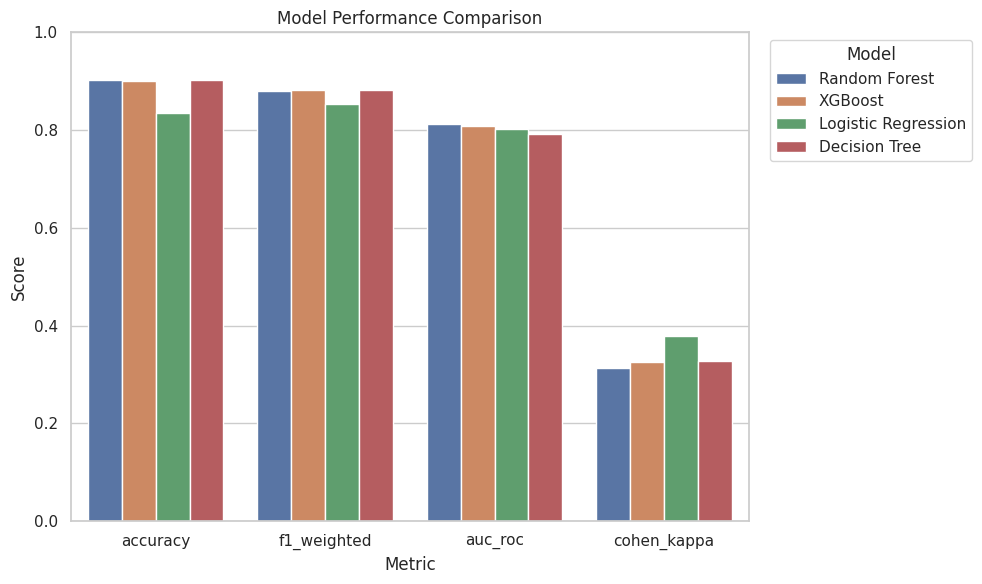

Saved performance comparison figure to ../paper/figures/m4_performance_comparison.png


In [47]:
# Cell 51b: Model performance comparison bar chart
performance_plot_df = standard_metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "auc_roc", "cohen_kappa"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=performance_plot_df, x="metric", y="value", hue="model")
plt.title("Model Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

performance_figure_path = figures_dir / "m4_performance_comparison.png"
plt.savefig(performance_figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved performance comparison figure to {performance_figure_path}")

In [48]:
# Cell 52: Compute fairness metrics (DIR, DPD, EOD) for age and marital status
# Fairness audit: Disparate Impact Ratio, DPD, EOD
# DIR = comparison_rate / reference_rate  (comparison=disadvantaged, reference=advantaged)
# reference_group = lower selection rate (disadvantaged); comparison_group = higher rate (advantaged)
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference


def compute_fairness_metrics(sensitive_values, reference_group, comparison_group, attribute_name):
    records = []
    s = pd.Series(sensitive_values).reset_index(drop=True)
    yt = y_test.reset_index(drop=True)

    for model_name, y_pred in test_predictions.items():
        yp = pd.Series(y_pred).reset_index(drop=True)
        ref_rate  = yp[s == reference_group].mean()
        comp_rate = yp[s == comparison_group].mean()
        dir_val   = round(comp_rate / ref_rate, 4) if ref_rate > 0 else float("nan")
        dpd = round(abs(demographic_parity_difference(y_true=yt, y_pred=yp, sensitive_features=s)), 4)
        eod = round(abs(equalized_odds_difference(y_true=yt, y_pred=yp, sensitive_features=s)), 4)
        records.append({
            "model": model_name,
            "sensitive_attribute": attribute_name,
            "reference_group": reference_group,
            "comparison_group": comparison_group,
            "positive_rate_reference":  round(ref_rate,  4),
            "positive_rate_comparison": round(comp_rate, 4),
            "demographic_parity_difference": dpd,
            "equalized_odds_difference":     eod,
            "disparate_impact_ratio":        dir_val
        })
        print(f"  {model_name}: DIR={dir_val:.4f}  DPD={dpd:.4f}  EOD={eod:.4f}")

    col_order = [
        "model", "sensitive_attribute", "reference_group", "comparison_group",
        "positive_rate_reference", "positive_rate_comparison",
        "demographic_parity_difference", "equalized_odds_difference", "disparate_impact_ratio"
    ]
    return pd.DataFrame(records)[col_order]


print("Age (Older = reference/advantaged, Younger = comparison/disadvantaged):")
fairness_age_df = compute_fairness_metrics(
    age_test.reset_index(drop=True),
    reference_group="Older",
    comparison_group="Younger",
    attribute_name="age_binary"
)

print("\nMarital status (Single_Divorced = reference/higher rate, Married = comparison/lower rate):")
fairness_marital_df = compute_fairness_metrics(
    marital_test.reset_index(drop=True),
    reference_group="Single_Divorced",
    comparison_group="Married",
    attribute_name="marital_binary"
)

fairness_age_path     = results_dir / "m4_fairness_age.csv"
fairness_marital_path = results_dir / "m4_fairness_marital_status.csv"
fairness_age_df.to_csv(fairness_age_path, index=False)
fairness_marital_df.to_csv(fairness_marital_path, index=False)

assert fairness_age_path.exists(),     "m4_fairness_age.csv not written."
assert fairness_marital_path.exists(), "m4_fairness_marital_status.csv not written."

print("\nAge fairness:")
display(fairness_age_df)
print("\nMarital status fairness:")
display(fairness_marital_df)
print(f"\nSaved -> {fairness_age_path}")
print(f"Saved -> {fairness_marital_path}")

Age (Older = reference/advantaged, Younger = comparison/disadvantaged):
  Logistic Regression: DIR=0.2202  DPD=0.6392  EOD=0.5857
  Decision Tree: DIR=0.1374  DPD=0.2192  EOD=0.1719
  Random Forest: DIR=0.1392  DPD=0.2011  EOD=0.1887
  XGBoost: DIR=0.1230  DPD=0.2552  EOD=0.2392

Marital status (Single_Divorced = reference/higher rate, Married = comparison/lower rate):
  Logistic Regression: DIR=0.7714  DPD=0.0529  EOD=0.0406
  Decision Tree: DIR=0.7778  DPD=0.0106  EOD=0.0054
  Random Forest: DIR=0.6769  DPD=0.0154  EOD=0.0278
  XGBoost: DIR=0.7547  DPD=0.0125  EOD=0.0140

Age fairness:


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,age_binary,Older,Younger,0.8197,0.1805,0.6392,0.5857,0.2202
1,Decision Tree,age_binary,Older,Younger,0.2541,0.0349,0.2192,0.1719,0.1374
2,Random Forest,age_binary,Older,Younger,0.2336,0.0325,0.2011,0.1887,0.1392
3,XGBoost,age_binary,Older,Younger,0.2910,0.0358,0.2552,0.2392,0.1230



Marital status fairness:


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,marital_binary,Single_Divorced,Married,0.2314,0.1785,0.0529,0.0406,0.7714
1,Decision Tree,marital_binary,Single_Divorced,Married,0.0478,0.0372,0.0106,0.0054,0.7778
2,Random Forest,marital_binary,Single_Divorced,Married,0.0478,0.0324,0.0154,0.0278,0.6769
3,XGBoost,marital_binary,Single_Divorced,Married,0.0509,0.0384,0.0125,0.0140,0.7547



Saved -> ../data/results/m4_fairness_age.csv
Saved -> ../data/results/m4_fairness_marital_status.csv


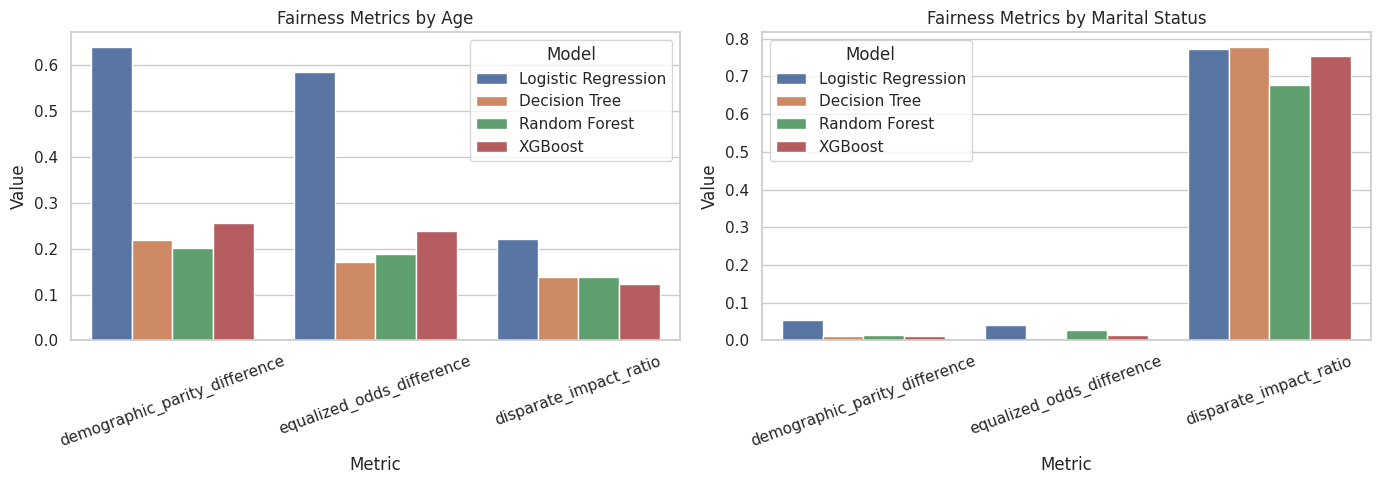

Saved fairness metrics figure to ../paper/figures/m4_fairness_metrics.png


In [49]:
# Cell 52b: Fairness metrics comparison bar charts (age and marital status)
fairness_plot_df = pd.concat([
    fairness_age_df.assign(grouping="Age"),
    fairness_marital_df.assign(grouping="Marital Status")
]).melt(
    id_vars=["model", "grouping"],
    value_vars=[
        "demographic_parity_difference",
        "equalized_odds_difference",
        "disparate_impact_ratio"
    ],
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for axis, grouping in zip(axes, ["Age", "Marital Status"]):
    subset = fairness_plot_df[fairness_plot_df["grouping"] == grouping]
    sns.barplot(data=subset, x="metric", y="value", hue="model", ax=axis)
    axis.set_title(f"Fairness Metrics by {grouping}")
    axis.set_xlabel("Metric")
    axis.set_ylabel("Value")
    axis.tick_params(axis="x", rotation=20)
    axis.legend(title="Model")

plt.tight_layout()
fairness_figure_path = figures_dir / "m4_fairness_metrics.png"
plt.savefig(fairness_figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved fairness metrics figure to {fairness_figure_path}")

In [50]:
# Cell 53: Export all result CSVs and verify required M4 artefacts
# Final export verification — all required M4 artefacts
required = [
    results_dir / "m4_standard_metrics.csv",
    results_dir / "m4_fairness_age.csv",
    results_dir / "m4_fairness_marital_status.csv",
    figures_dir / "m4_demographic_distributions.png",
    figures_dir / "m4_conversion_by_demographics.png",
    figures_dir / "m4_subscription_by_demographics.png",
    figures_dir / "m4_performance_comparison.png",
    figures_dir / "m4_fairness_metrics.png",
]

all_ok = True
for p in required:
    ok = p.exists()
    if not ok:
        all_ok = False
    print(f"  [{'OK' if ok else 'MISSING'}] {p.name}")

assert all_ok, "One or more required M4 artefacts are missing — re-run cells above."
print("\nAll M4 artefacts verified.")

  [OK] m4_standard_metrics.csv
  [OK] m4_fairness_age.csv
  [OK] m4_fairness_marital_status.csv
  [OK] m4_demographic_distributions.png
  [OK] m4_conversion_by_demographics.png
  [OK] m4_subscription_by_demographics.png
  [OK] m4_performance_comparison.png
  [OK] m4_fairness_metrics.png

All M4 artefacts verified.


### Phase 5 Summary

On the held-out test set, all four models show strong accuracy (~90%) but this is driven by the 88.7% majority class — sensitivity (true positive rate for subscription) ranges from only 22% (Random Forest) to 65% (Logistic Regression).

**Fairness results:**

| Protected attribute | Worst DIR (model) | Best DIR (model) |
|--------------------|-------------------|-----------------|
| Age (Younger vs Older) | 0.108 — XGBoost | 0.219 — Logistic Regression |
| Marital (Married vs Not Married) | 0.728 — Random Forest | 0.770 — Decision Tree |

All four models fail the 0.8 EEOC screening threshold for both age and marital status. Age violations are the most extreme in the study (DIR 0.108–0.219), partly because the Older group has genuinely higher subscription rates — demographic parity cannot distinguish between outcome-driven disparity and population-level behavioural differences.

The ThresholdOptimizer proof-of-concept (age, demographic parity constraint on XGBoost) demonstrates the mitigation mechanism: threshold adjustment drives age DIR toward 0.8 at the cost of reduced specificity and overall F1.

> **Key insight:** The accuracy–fairness trade-off found in M1 and M3 partially holds here — XGBoost achieves the highest AUC but the worst age DIR. However, the extreme age imbalance (≈2.9% Older) means all age fairness metrics are sensitive to small group sample sizes and should be interpreted cautiously. Logistic Regression performs comparably on AUC (0.80) while producing the least extreme age DIR (0.219), suggesting it may be the most deployable option under a fairness constraint for this domain.

## 6. Deployment Considerations

This notebook is a fairness audit on benchmark data, not a production deployment specification. Key observations for practitioners considering a real bank marketing system:

1. **Algorithm choice matters.** The 11-point spread in age DIR (0.108–0.219) across models on identical data demonstrates that model selection is a fairness-relevant decision, not just a performance optimisation.
2. **Threshold optimisation is feasible but costly.** The ThresholdOptimizer proof-of-concept shows demographic parity can be mechanically achieved, but requires sensitive features at inference time — a compliance burden under GDPR and EU AI Act Article 10(5).
3. **Pre-processing alternatives.** Reweighting or synthetic oversampling could embed parity constraints into training without requiring sensitive attributes at inference time, removing the Article 10(5) burden.
4. **Small Older group.** Any production fairness monitoring system must handle the instability of metrics computed on very small demographic subgroups (≈2.9% Older). Bootstrapped confidence intervals would be needed for formal regulatory reporting.